# Computer Vision - P2

==============================================================================================
## Practicum 2: Filtering and edge detection

==============================================================================================

The main topics are:
1. Image smoothing and convolution (exercises 2.1, 2.2, 2.3 and 2.4)
2. Edge detection (exercises 2.5, 2.6 and 2.7)

In order to complete this practicum, the following concepts need to be understood: linear filters, histograms, convolutions, and edges.

The following chapters of the book "Computer Vision: Algorithms and Applications" by Richard Szeliski provide additional information:
* Chapter 3. Image processing: Point operators & linear filtering.
* Chapter 4. Feature detection and matching: Edges.

### 2.1 RGB histogram visualization

a) Read the image `./images_notebook/oryx.png` and visualize the RGB image as well as each of its channels separately (R, G, and B). Print the image shape and data type.

<img src="images_notebook/oryx.jpg">

**Note:** Before applying the histogram, you should pass the image into float.

uint8
(800, 1200, 3)


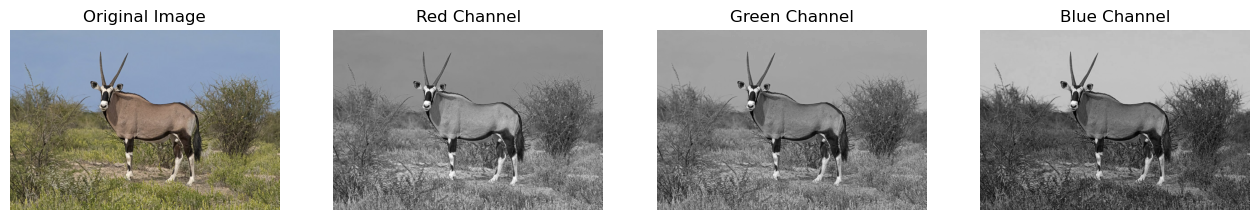

In [2]:
#your solution

from skimage import io
from matplotlib import pyplot as plt
import numpy as np
from skimage import img_as_float
from skimage.color import rgb2gray

img_oryx = io.imread("images_notebook/oryx.jpg")

print(img_oryx.dtype)
print(img_oryx.shape)

# Create a 1x4 figure to display the image as well as the three color channels (as grayscale images)
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

# Display the original image
ax[0].imshow(img_oryx)
# Remove the ticks and axes
ax[0].axis("off")
# Add a title to the image
ax[0].set_title("Original Image")

img_oryx_r = img_oryx.copy()
img_oryx_r = img_oryx_r[:,:,0]
# Display the image
ax[1].imshow(img_oryx_r, cmap="gray", vmin=0, vmax=255)
# Remove the ticks and axes
ax[1].axis("off")
# Add a title to the image
ax[1].set_title("Red Channel")

img_oryx_g = img_oryx.copy()
img_oryx_g = img_oryx_g[:,:,1]
# Display the image
ax[2].imshow(img_oryx_g, cmap="gray", vmin=0, vmax=255)
# Remove the ticks and axes
ax[2].axis("off")
# Add a title to the image
ax[2].set_title("Green Channel")

img_oryx_b = img_oryx.copy()
img_oryx_b = img_oryx_b[:,:,2]
# Display the image
ax[3].imshow(img_oryx_b, cmap="gray", vmin=0, vmax=255)
# Remove the ticks and axes
ax[3].axis("off")
# Add a title to the image
ax[3].set_title("Blue Channel")
plt.show()

b) Make a function `im_hist(im,  nbins=8)` to visualize the histogram of the RGB, and grayscale images. What is the histogram representing for an image?

The plotted histogram must accomplish these requirements (see image bellow as an example of histogram extraction):

- Obtain the histogram with 16, 32, 64 and 256 bins. What are the bins representing?

- Visualize the histogram of each channel and the gray level image separately and compare them. Comment their differences (between different channels and different number of bins).

**Note:** What type should be the image in order to compute the histogram? Check using different bins for the histogram.

**Hint** : the `exposure` module within the `skimage` library makes the histogram extraction easy!

**Help:** [matplotlib image tutorial](https://matplotlib.org/users/image_tutorial.html)

<img src='images_notebook/histograms.png'>

In [3]:
#your solution
from skimage import exposure

def im_hist(im, nbins=128):
    # Convert the image to float (range between 0 and 1)
    im = img_as_float(im)

    # Compute the grayscale histogram using the specified number of bins
    hist, bins = exposure.histogram(rgb2gray(im), nbins=nbins)

    # Compute the histograms for the red, green, and blue channels
    hist_r, bins_r = exposure.histogram(im[:, :, 0], nbins=nbins)
    hist_g, bins_g = exposure.histogram(im[:, :, 1], nbins=nbins)
    hist_b, bins_b = exposure.histogram(im[:, :, 2], nbins=nbins)

    # Calculate width for the bar plot
    width = 0.2  # Fixed width factor for bars

    # Generate shifted x-axis values to prevent overlapping between channels
    inds = np.arange(nbins)  # Common indices for all histograms
    bins_r = inds + width     # Shift red histogram bars
    bins_g = inds + 2 * width # Shift green histogram bars
    bins_b = inds + 3 * width # Shift blue histogram bars

    # Create a figure with a defined size
    plt.figure(figsize=(10, 4))

    # Plot the histograms as bar plots with corresponding colors
    plt.bar(inds, hist, width=width, color="gray", label="Gray")  # Grayscale histogram
    plt.bar(bins_r, hist_r, width=width, color="red", label="Red") # Red channel histogram
    plt.bar(bins_g, hist_g, width=width, color="green", label="Green") # Green channel histogram
    plt.bar(bins_b, hist_b, width=width, color="blue", label="Blue") # Blue channel histogram

    # Add a legend to the plot
    plt.legend()

    # Show the plot
    plt.show()


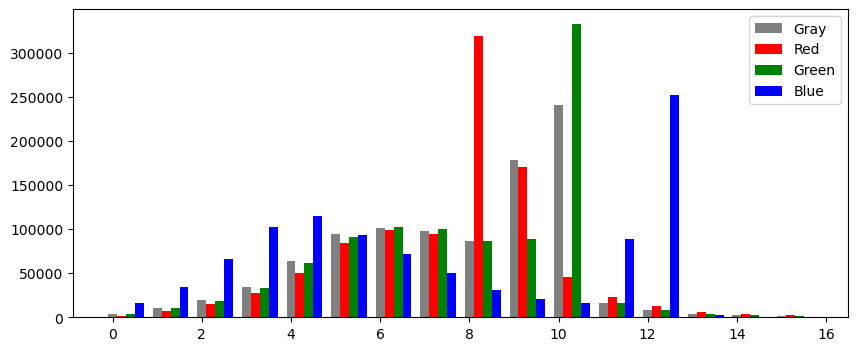

In [4]:
im_hist(img_oryx, nbins=16)

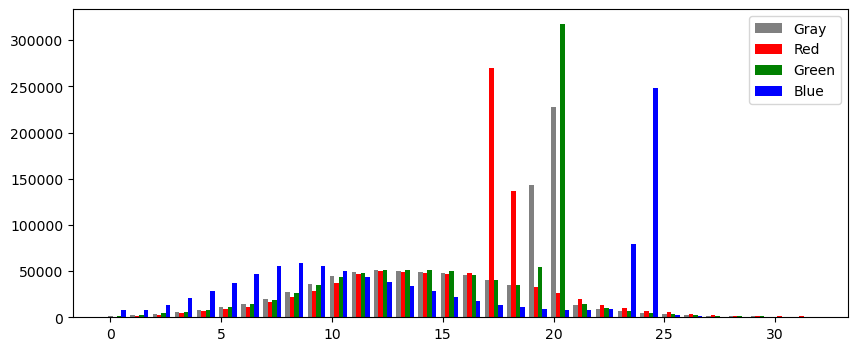

In [5]:
im_hist(img_oryx, nbins=32)

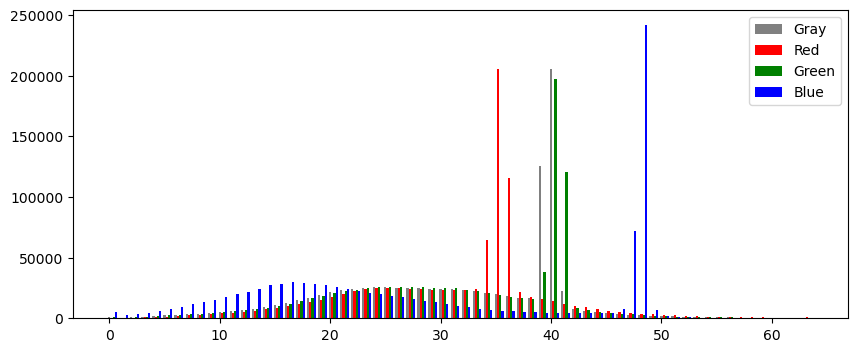

In [6]:
im_hist(img_oryx, nbins=64)

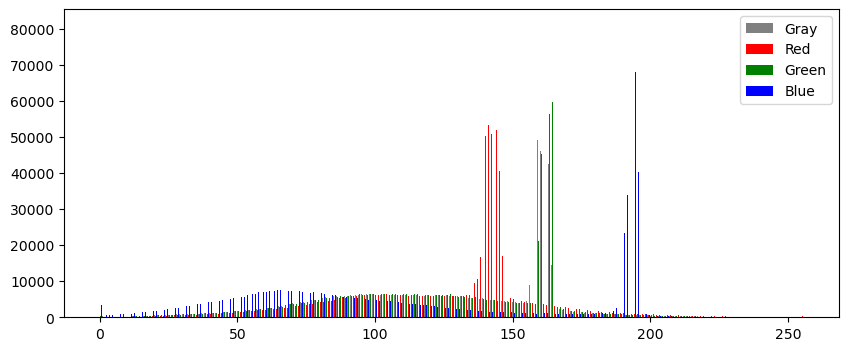

In [7]:
im_hist(img_oryx, nbins=256)

Explanation:

- Grayscale Histogram: Shows the overall intensity distribution across the image.
- RGB Histograms: Each of the red, green, and blue histograms shows how much of each color is present at each intensity.
- Bins: The number of bins defines the granularity of the histogram. More bins give a finer view of intensity differences, while fewer bins result in a coarser representation.
    - Smaller bins (e.g., 16, 32): Fewer bins result in a more generalized view of pixel distribution. Peaks and intensity levels are combined into broader ranges, making it easier to spot general trends but harder to see fine details.
    - Larger bins (e.g., 64, 256): More bins mean a finer granularity, which shows more details of pixel intensities. This can reveal subtle color changes but may make the histogram noisier and harder to interpret.

To compute histograms, the image should be in a float format with normalized values (between 0 and 1). This ensures proper handling by the `exposure.histogram()` function.

### 2.2 Grayscale and RGB images filtering (convolutions)

a) Read the image `./images_notebook/oryx.png`. Reshape the image to $256x256$ pixels and convert to gray scale (i.e. `oryx_gray`). We are going to apply:

1. Convolve `oryx_gray` with a horizontal mask `mask_h1d=[[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]]` using the function `ndimage.convolve()` of the package `scipy`.
2. Convolve `oryx_gray` with a transposed version of the mask in (2).
3. Convolve `oryx_gray` with a uniform `two-dimensional` mask of dimensions 15x15 with all values set to 1.

Check the maximum and minimum values, as well as the data type of each imagea.

- Is the type of the mask important for the convolution? What effect does each of the masks produce on the original image? Compare the results.


**Note:** The command `convolve` performs a multidimensional convolution! A vector should be represented as: [[1,...1]].

**Note:** Remember that before applying the `convolve` function the mask must be normalized (i.e. all values in the mask must sum 1).


In [8]:
#your solution

from skimage.transform import resize
from scipy.ndimage import convolve

# Use skimage to scale the image oryx to a 256x256 image
oryx_resized = img_oryx.copy() # Here you can get the image previously loaded or load it again
oryx_resized = resize(oryx_resized, (256, 256))
oryx_gray = rgb2gray(oryx_resized)
# Print the minimum and maximum values of the resized image, as well as its data type
print("Original")
print("Min:", np.min(oryx_resized))
print("Max:", np.max(oryx_resized))
print("Data type:", oryx_resized.dtype)

mask_h1d=[[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]]
# Normalize the mask
mask_h1d = np.array(mask_h1d) / np.sum(mask_h1d)
oryx_h1d = convolve(oryx_gray, mask_h1d)
# Print the minimum and maximum values of the convolved image, as well as its data type
print("H1D")
print("Min:", np.min(oryx_h1d))
print("Max:", np.max(oryx_h1d))
print("Data type:", oryx_h1d.dtype)

mask_h1d = mask_h1d.T
oryx_v1d = convolve(oryx_gray, mask_h1d)
# Print the minimum and maximum values of the convolved image, as well as its data type
print("V1D")
print("Min:", np.min(oryx_v1d))
print("Max:", np.max(oryx_v1d))
print("Data type:", oryx_v1d.dtype)

mask_2d = np.ones((15, 15))
# Normalize the mask
mask_2d = mask_2d / np.sum(mask_2d)
oryx_2d = convolve(oryx_gray, mask_2d)
# Print the minimum and maximum values of the convolved image, as well as its data type
print("2D")
print("Min:", np.min(oryx_2d))
print("Max:", np.max(oryx_2d))
print("Data type:", oryx_2d.dtype)

Original
Min: 0.009671432538522708
Max: 0.9909041213704801
Data type: float64
H1D
Min: 0.07930344715971478
Max: 0.7390640460544804
Data type: float64
V1D
Min: 0.0975615318244063
Max: 0.8313810550732913
Data type: float64
2D
Min: 0.16119877602852695
Max: 0.6406818647557891
Data type: float64


1D Horizontal and Vertical Masks: These masks smooth the image along only one direction (either horizontal or vertical), which causes some directional blurring while retaining details in the orthogonal direction. As a result, you observe a modest reduction in the pixel intensity range.

2D Mask: This mask smooths the image in both directions simultaneously, which results in a more pronounced blurring effect. Consequently, this reduces the intensity range significantly, as it averages over a larger neighborhood of pixels.

b) Visualize the four images, `oryx_gray` and the output of each step (1 to 3) in a single figure, with the corresponding titles.


Note: Remember that `matplotlib.pyplot` automatically rescales the values of the image before displaying them. Visualize with and without pixel values range rescaling.


Text(0.5, 1.0, '2D Mask')

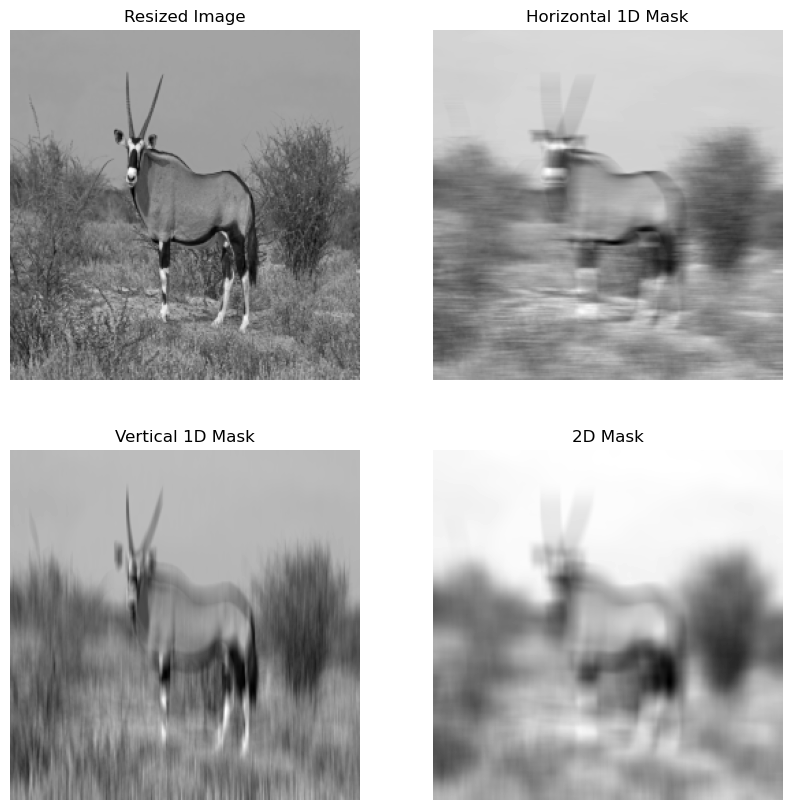

In [9]:
#your solution
# Show all the images in a 2x2 grid
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

# Display the original image
ax[0, 0].imshow(oryx_gray, cmap="gray")
ax[0, 0].axis("off")
ax[0, 0].set_title("Resized Image")

# Display the horizontal 1D mask
ax[0, 1].imshow(oryx_h1d, cmap="gray")
ax[0, 1].axis("off")
ax[0, 1].set_title("Horizontal 1D Mask")

# Display the vertical 1D mask
ax[1, 0].imshow(oryx_v1d, cmap="gray")
ax[1, 0].axis("off")
ax[1, 0].set_title("Vertical 1D Mask")

# Display the 2D mask
ax[1, 1].imshow(oryx_2d, cmap="gray")
ax[1, 1].axis("off")
ax[1, 1].set_title("2D Mask")

c) Can we convolve a color (RGB) image?

Implement a function `conv_coor(image, mask)` that applies a 3-channel filter.  Reshape the original `oryx.png` image to $256x256$ pixels and try your funcion, using a 7x7 uniform mask.


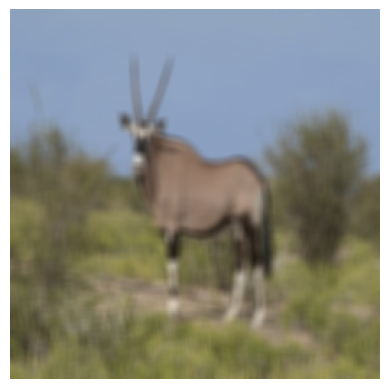

In [23]:
#your solution
def conv_coor(image, mask):
    # Apply the mask to each channel (R, G, B) separately
    result_image = np.zeros_like(image)
    for i in range(3):
        result_image[:, :, i] = convolve(image[:, :, i], mask/np.sum(mask))
    return result_image

mask_3d = np.ones((7, 7))

oryx_3d = conv_coor(img_as_float(oryx_resized), mask_3d)

plt.imshow(oryx_3d)
plt.axis("off")
plt.show()

### 2.3 Effect of image scale on convolutions

a) Resize an image and observe the variations in the histograms.

1. Reduce `oryx_gray` 20 times, and check the histogram (i.e. nbins = 32)
2. Augment `oryx_gray` 20 times, and check its histogram (i.e. nbins = 32)

Is there any difference? Please, comment what happens and why.


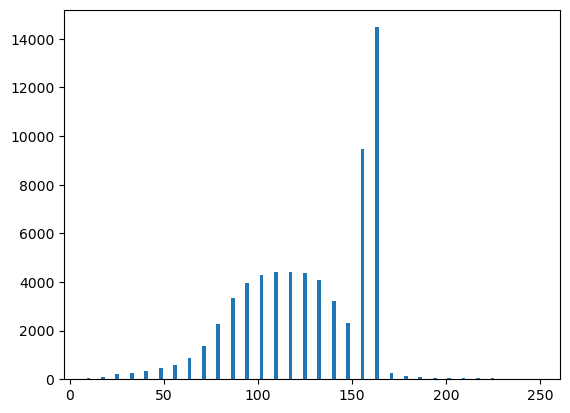

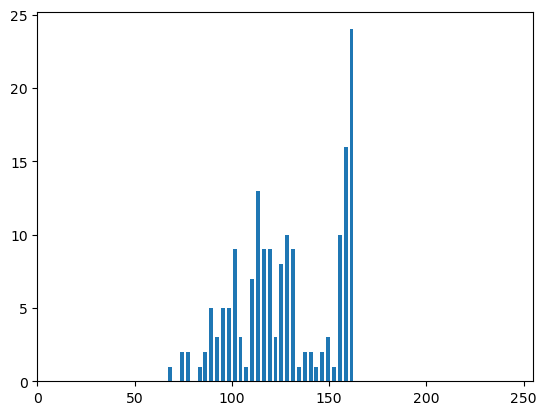

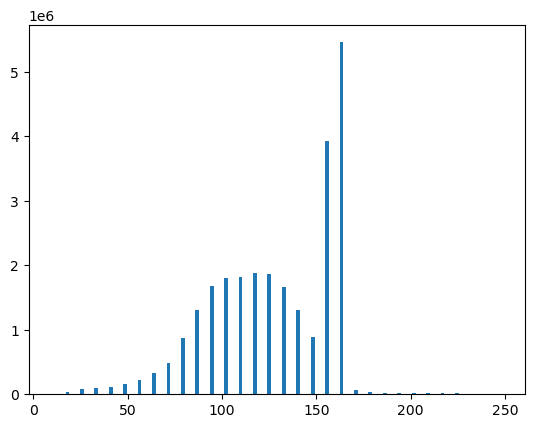

In [24]:
#your solution

from skimage.transform import rescale

# Plot the histogram of the image oryx_gray
hist, bins = exposure.histogram(oryx_gray, nbins=32)
plt.bar(255*bins, hist, width=2)
plt.show()

# Rescale (10 times smaller) the image oryx_gray
oryx_rescaled = oryx_gray.copy()
oryx_rescaled = rescale(oryx_rescaled, 1/20)
hist, bins = exposure.histogram(oryx_rescaled, nbins=32)

# Plot the histogram of the rescaled image
plt.bar(255*bins, hist, width=2)
# Set the x-axis limits to [0, 255]
plt.xlim([0, 255])
plt.show()

# Rescale (10 times bigger) the image oryx_gray
oryx_rescaled = oryx_gray.copy()
oryx_rescaled = rescale(oryx_rescaled, 20)
hist, bins = exposure.histogram(oryx_rescaled, nbins=32)

# Plot the histogram of the rescaled image
plt.bar(255*bins, hist, width=2)
plt.show()

**Explanation**

The histogram of the original image (oryx_gray) shows the distribution of pixel intensities across 64 bins. The image's pixel values range from 0 (black) to 255 (white), with most values concentrated in the mid-intensity range.

When we reduce the image size by 20 times, the histogram becomes sparse. This is expected, as downsampling results in a significant loss of detail. Many neighboring pixel intensities are merged or averaged, leading to fewer distinct intensity values. The reduction in pixel resolution also causes lower overall pixel counts in the histogram. This explains why the histogram peaks are shorter and less defined than those of the original image.

Upsampling the image by 20 times results in a histogram that retains the shape of the original histogram, but with significantly higher pixel counts in each bin. This occurs because the upsampling process involves interpolating new pixels based on neighboring values, which increases the total number of pixels while preserving the original intensity distribution. Upsampling increases the number of pixels but does not introduce new intensity levels.

b) Apply a convolution (7x7 uniform mask) on the resized images, calculate the histograms and compare the results.

1. Convolve the original `oryx_gray`image and calculate its histogram.
2. Convolve the reduced `oryx_gray` image 20 times and calculate its histogram.
3. Convolve the augmented `oryx_gray` image 20 times and calculate its histogram.

Comment what happens and why.

b) Aplique una convolución (máscara uniforme 7x7) a las imágenes redimensionadas, calcule los histogramas y compare los resultados.

1. Convolucione la imagen original «oryx_gray» y calcule su histograma.
2. Convolucione la imagen reducida «oryx_gray» 20 veces y calcule su histograma.
3. Convolucione la imagen aumentada «oryx_gray» 20 veces y calcule su histograma.

Comente qué sucede y por qué.

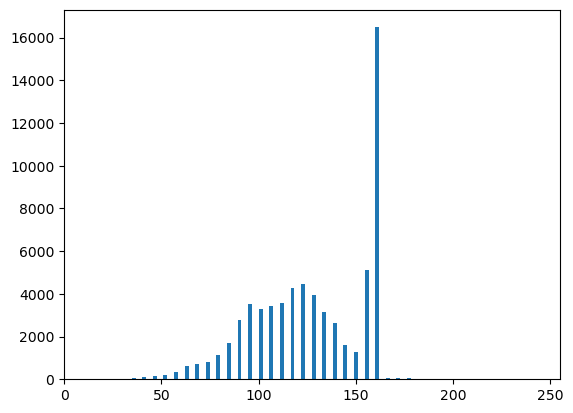

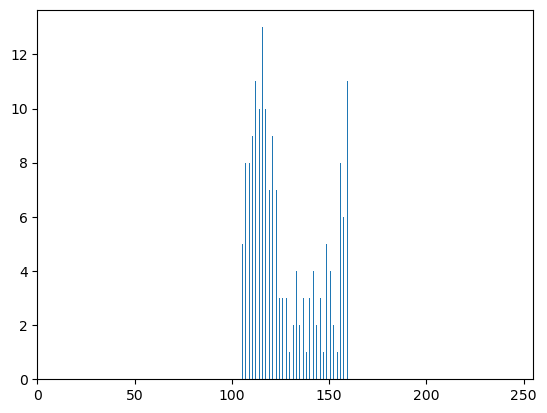

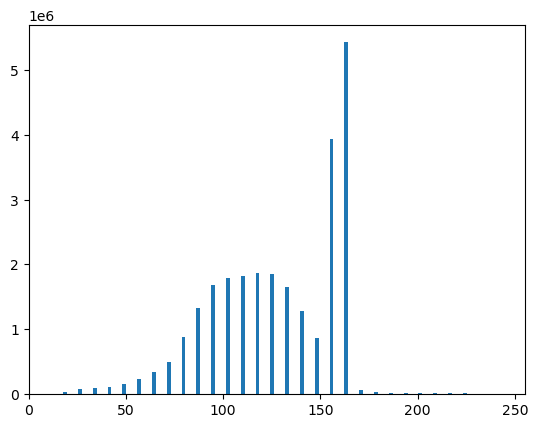

In [25]:
#your solution

mask = np.ones((7,7))
mask = mask/np.sum(mask)

oryx_blurred = convolve(img_as_float(oryx_gray), mask)

oryx_small_blurred = convolve(rescale(img_as_float(oryx_gray), 1/20), mask)
oryx_big_blurred = convolve(rescale(img_as_float(oryx_gray), 20), mask)


# Compute histograms
hist, bins = exposure.histogram(oryx_blurred, nbins=32)
hist_small, bins_small = exposure.histogram(oryx_small_blurred, nbins=32)
hist_big, bins_big = exposure.histogram(oryx_big_blurred, nbins=32)

# Plot histograms
plt.bar(255*bins, hist, width=2, label="Original")
plt.xlim([0, 255])
plt.show()
plt.bar(255*bins_small, hist_small, width=0.5, label="Small")
plt.xlim([0, 255])
plt.show()
plt.bar(255*bins_big, hist_big, width=2, label="Big")
plt.xlim([0, 255])
plt.show()

**Explanation**

After applying a uniform 7×7 convolution mask, the image is blurred, meaning the high-frequency details (such as edges and sharp transitions) are smoothed out. This causes the intensity values in the image to become more similar across neighboring pixels, which reduces the variance in the pixel intensities. As a result, the histogram of the convolved image shows a more pronounced peak in the mid-intensity range (around 120-150), as the blurring reduces intensity variation.


The downsampled image has fewer pixels, so the resulting histogram is more sparse, with fewer distinct intensity values. After convolution, the histogram shows a reduced range of intensities, and there are fewer unique bins. This is because the downsampled image has already lost a significant amount of detail, so convolution has less of an effect. The histogram is more clustered, reflecting the loss of intensity diversity due to both downsampling and blurring. For example, values below 100 are now lost.

The upsampled image contains many more pixels than the original. The resulting histogram (after convolution) closely resembles the original but on a much larger scale, with very high bin counts. The peaks are similar in shape to the original, but because the image contains many more pixels, the bin counts are much higher. The convolution smooths high-frequency details in the upsampled image, creating a blurring effect, but the intensity range does not become more uniform compared to the original. The distribution of intensities remains similar to that of the original image, with the smoothing mainly reducing variations in pixel intensity.

### 2.4 Image processing with weighting and non-linear filters

a) Generate the following kernels and apply them to the `oryx_gray` image:

1. Gaussian kernel with sigma = 1
2. Gaussian kernel with 3 different sigma values. Which is the most adequate value for keeping the main objects and structures of the image?
3. Median filter with different mask shapes: disk, rectangle, and diamond. What is the effect of using different kinds of filters on the original image?

Comment the effect of using different kinds of filters on the original image.

**Hint:** Search for the [skimage.filters function](https://scikit-image.org/docs/stable/api/skimage.filters.html) for creating the different filters.

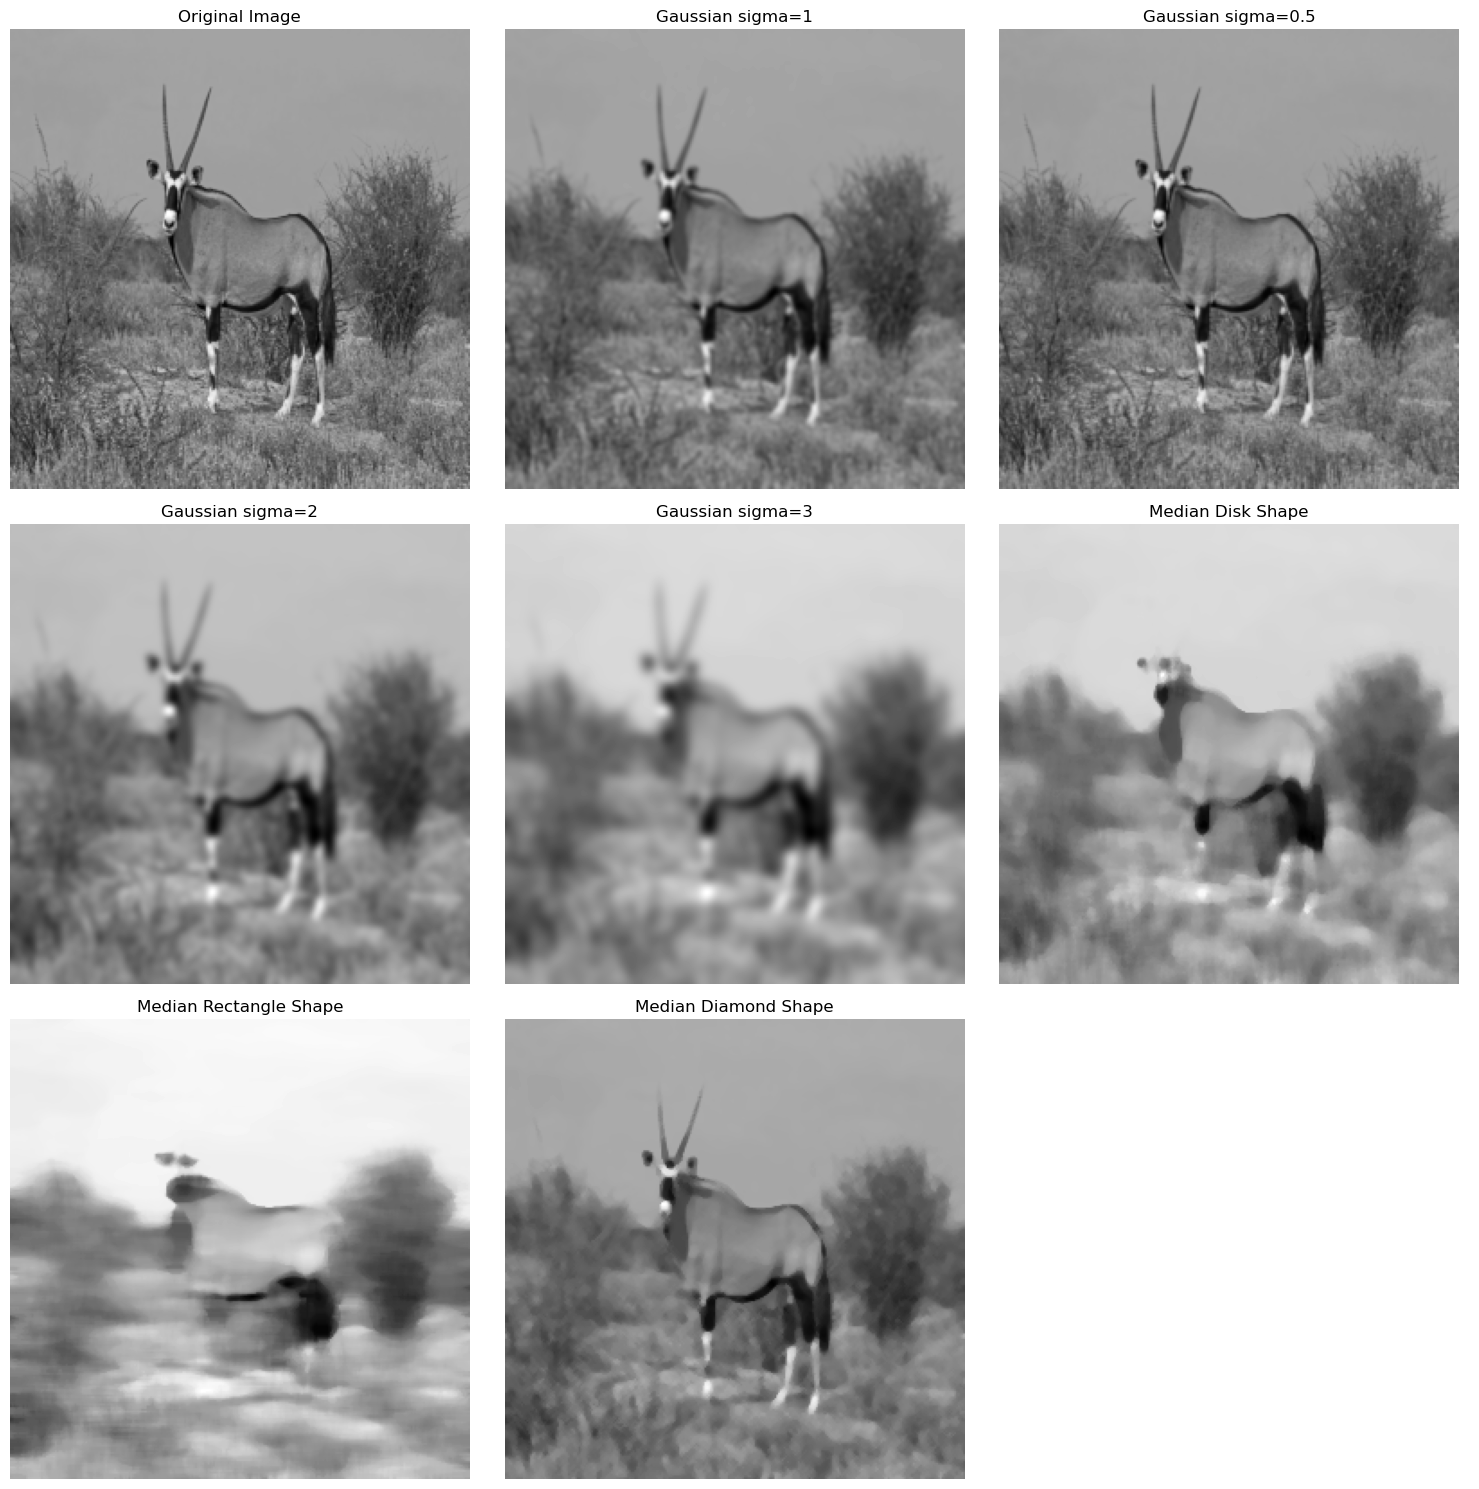

In [13]:
#your solution

from skimage import filters, img_as_float, morphology
from skimage.filters import gaussian, median
from skimage.morphology import disk, rectangle, diamond

# Convert image to float for better processing
oryx_gray_float = img_as_float(oryx_gray)

# 1. Apply Gaussian filter with sigma = 1
gaussian_sigma_1 = gaussian(oryx_gray_float, sigma=1)

# 2. Apply Gaussian filter with three different sigma values
gaussian_sigma_0_5 = gaussian(oryx_gray_float, sigma=0.5)
gaussian_sigma_2 = gaussian(oryx_gray_float, sigma=2)
gaussian_sigma_3 = gaussian(oryx_gray_float, sigma=3)

# 3. Apply median filters with different mask shapes
median_disk = median(oryx_gray_float, morphology.disk(5))
median_rectangle = median(oryx_gray_float, morphology.rectangle(5, 20))
median_diamond = median(oryx_gray_float, morphology.diamond(3))

# Plot results
fig, ax = plt.subplots(3, 3, figsize=(15, 15))

# Original Image
ax[0, 0].imshow(oryx_gray_float, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')

# Gaussian with sigma = 1
ax[0, 1].imshow(gaussian_sigma_1, cmap='gray')
ax[0, 1].set_title('Gaussian sigma=1')
ax[0, 1].axis('off')

# Gaussian with sigma = 0.5
ax[0, 2].imshow(gaussian_sigma_0_5, cmap='gray')
ax[0, 2].set_title('Gaussian sigma=0.5')
ax[0, 2].axis('off')

# Gaussian with sigma = 2
ax[1, 0].imshow(gaussian_sigma_2, cmap='gray')
ax[1, 0].set_title('Gaussian sigma=2')
ax[1, 0].axis('off')

# Gaussian with sigma = 3
ax[1, 1].imshow(gaussian_sigma_3, cmap='gray')
ax[1, 1].set_title('Gaussian sigma=3')
ax[1, 1].axis('off')

# Median filter with disk
ax[1, 2].imshow(median_disk, cmap='gray')
ax[1, 2].set_title('Median Disk Shape')
ax[1, 2].axis('off')

# Median filter with rectangle
ax[2, 0].imshow(median_rectangle, cmap='gray')
ax[2, 0].set_title('Median Rectangle Shape')
ax[2, 0].axis('off')

# Median filter with diamond
ax[2, 1].imshow(median_diamond, cmap='gray')
ax[2, 1].set_title('Median Diamond Shape')
ax[2, 1].axis('off')

ax[2, 2].axis('off')

plt.tight_layout()
plt.show()

1. **Gaussian Kernel with Different Sigma Values**:

- **Gaussian (Sigma = 0.5)**:
  The minimal smoothing effect from this filter preserves the finer details of the image, including the oryx's horns. The image retains its overall sharpness, with only slight noise reduction. The background vegetation and edges remain clear.
- **Gaussian (Sigma = 1)**:
  This filter introduces a moderate smoothing effect. While the image remains reasonably sharp, some fine details, such as the texture of the oryx’s fur, are slightly blurred. However, the main structures, including the horns, are still preserved, making this an appropriate balance between noise reduction and detail retention.
- **Gaussian (Sigma = 2)**:
  With a higher sigma, the smoothing effect becomes more prominent, and fine details like the oryx's horns start to blur. The edges of the horns are less distinct, and much of the texture of the fur and background is lost. The image remains smooth but starts to lose important features.
- **Gaussian (Sigma = 3)**:
  This level of blurring is excessive for preserving fine details. The oryx’s horns and other small features are almost completely lost, blending into the background. The image appears overly smoothed, with large structures (like the oryx's body) being the only distinguishable features.



2. **Median Filters with Different Mask Shapes**:

- **Median (Disk Shape)**:
  The disk-shaped median filter effectively removes noise while maintaining some of the larger structures. However, **the fine details of the oryx’s horns are lost** in this filter. The disk shape smooths out the sharpness around small, thin features like the horns, making them blend with the sky. This is a downside of using a disk-shaped filter when trying to preserve very thin structures.
- **Median (Rectangle Shape)**:
  The rectangular-shaped median filter introduces even more pronounced distortions. Not only do **the horns of the oryx disappear**, but the rectangular shape also stretches and distorts the vertical and horizontal features of the image. The overall structure of the oryx is preserved, but the fine details, especially the horns, are heavily smoothed out. The rectangular filter is less suitable for preserving small, sharp features in natural images.
- **Median (Diamond Shape)**:
  The diamond-shaped median filter provides the best balance among the median filters. While there is some loss of detail, especially around the horns, they remain more visible compared to the disk and rectangle filters. This filter effectively reduces noise while retaining more of the original structure, especially in small features like the horns and edges of the oryx.



### Summary of Filter Effects:

- **Gaussian Filters**: Gaussian filters provide progressive blurring based on the sigma value. With **sigma = 0.5**, the horns and fine details are well-preserved. As the sigma increases, the smoothing effect causes more detail loss, particularly with sigma values of 2 and 3, where the horns and other fine structures are blurred out.
- **Median Filters**: Median filters generally preserve edges better than Gaussian filters, but different mask shapes affect the result. The **disk-shaped** and **rectangle-shaped filters** lead to a loss of the oryx’s horns and other fine features. The **diamond-shaped filter**, while still causing some smoothing, does a better job of preserving the horns and other important structures compared to the other median filter shapes.

b) **(Optional)** Apply the smoothing on some other images and present their results.

In [14]:
#your solution

### 2.5 Determine the optimal contour

a) Load the 'logo_pozo.jpg' image and visualize its contours.

<img src="images_notebook/logo_pozo.jpg" width="400" height="400">


Apply the different contour extraction tecniques introduced during the theory session and change any parameter if necessary for detecting the edges of the image:

1. Prewitt
2. Sobel
3. Canny

Use subplot and title to visualize the results.

#### **Questions**

- Which is the best countour detection technique?

- Which are the optimal parameters for this image?

- Is it necessary to normalize the mask as we do in the filtering applied for the smoothing?

**Hint**: use `skimage.feature.canny` for applying the canny filter and `skimage.filters` for the rest.

**(Optional)** Superimpose the contours over the image.

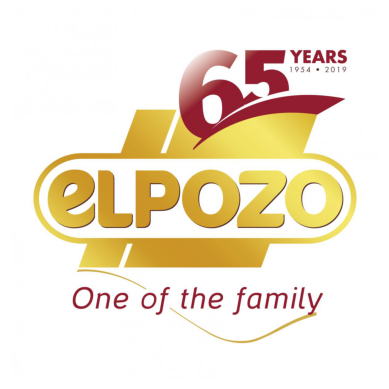

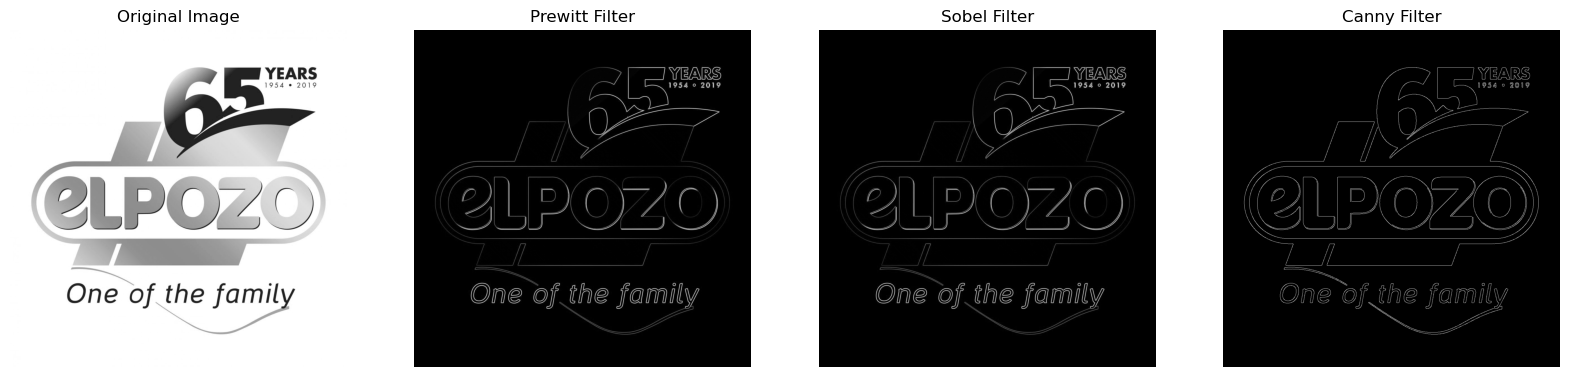

In [26]:
import warnings
warnings.filterwarnings("ignore")

"""Your Solution"""


from skimage.feature import canny
from skimage.filters import sobel, prewitt


logo = io.imread("images_notebook/logo_pozo.jpg")

plt.imshow(logo)
plt.axis("off")
plt.show()

logo_gray = rgb2gray(logo[:,:,:3])

logo_pre = prewitt(logo_gray)
logo_sob = sobel(logo_gray)
logo_canny = canny(logo_gray)

# Show all the images in a 1x4 grid
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

# Display the original image
ax[0].imshow(logo_gray, cmap="gray")
# Remove the ticks and axes
ax[0].axis("off")
# Add a title to the image
ax[0].set_title("Original Image")

ax[1].imshow(logo_pre, cmap="gray")
ax[1].axis("off")
ax[1].set_title("Prewitt Filter")

ax[2].imshow(logo_sob, cmap="gray")
ax[2].axis("off")
ax[2].set_title("Sobel Filter")

ax[3].imshow(logo_canny, cmap="gray")
ax[3].axis("off")
ax[3].set_title("Canny Filter")
plt.show()

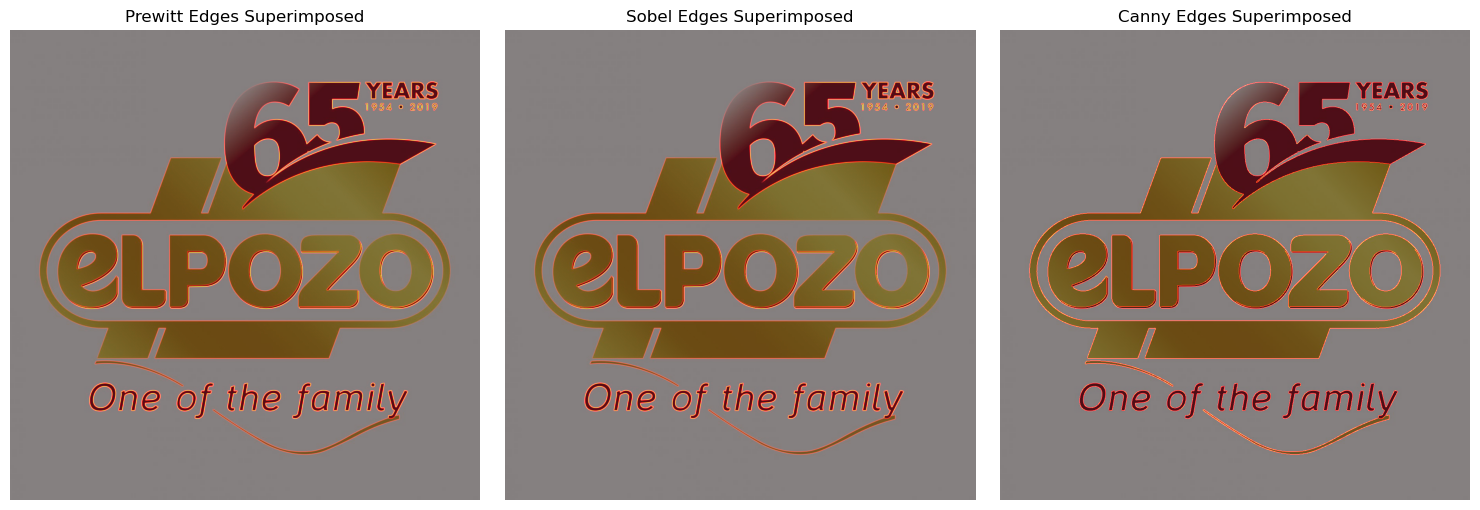

In [ ]:
# Superimpose contours on the original image
# Superponer contornos sobre la imagen original
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Prewitt contours
ax[0].imshow(logo, cmap='gray')
ax[0].imshow(logo_pre, cmap='hot', alpha=0.5)  # Use transparency (alpha) to overlay edges
ax[0].set_title("Prewitt Edges Superimposed")
ax[0].axis('off')

# Sobel contours
ax[1].imshow(logo, cmap='gray')
ax[1].imshow(logo_sob, cmap='hot', alpha=0.5)
ax[1].set_title("Sobel Edges Superimposed")
ax[1].axis('off')

# Canny contours
ax[2].imshow(logo, cmap='gray')
ax[2].imshow(logo_canny, cmap='hot', alpha=0.5)
ax[2].set_title("Canny Edges Superimposed")
ax[2].axis('off')

plt.tight_layout()
plt.show()


**Analysis**


Prewitt Filter:

The Prewitt filter provides a basic edge detection method that is relatively simple in terms of computation.
As seen in the result, the edges are well-defined but slightly less smooth compared to the Sobel or Canny methods. The letters in the "EL POZO" logo and the text below are detected clearly, but finer details such as the curved lines above "65" or the intricate details in the font are not as sharp.
Superimposed Image: The edges are visible, but the contours do not stand out as distinctly as in other methods. The Prewitt filter produces a good outline, but it may not be as precise for more complex logos or fine structures.

Sobel Filter:

The Sobel filter enhances the edge detection by calculating gradients in both the horizontal and vertical directions, leading to smoother and more distinct edges.
The result from the Sobel filter shows more defined edges compared to the Prewitt filter. The curves around "65" and the text are sharper. This makes it slightly better for contour detection, especially for logos with curved or diagonal elements.
Superimposed Image: The Sobel edges are more distinct when overlaid on the image, giving clearer contours compared to Prewitt. The text and logo structures are highlighted effectively without excessive noise or weak edges.

Canny Filter:

The Canny filter is the most sophisticated method used here, as it combines Gaussian smoothing with edge detection and edge tracking using hysteresis. It is excellent at detecting clear, continuous edges.
The Canny edge detection result shows the cleanest and most well-defined edges among the three techniques. The letters in the logo, as well as the details around "65," are detected precisely, with minimal noise and no unnecessary edge fragments.
Superimposed Image: The Canny edges stand out the most when superimposed on the original image. The contour lines are clean, and the overall structure of the logo remains intact. This makes it ideal for situations where fine, precise edge detection is required.

**Solution to questions**


- Which is the best contour detection technique?

The Canny filter is the best technique for detecting contours in this case. It produces the cleanest and most well-defined edges with minimal noise, making it ideal for precise contour detection in logos like the one used in this exercise.

- Which are the optimal parameters for this image?

For the Canny filter, a sigma value of 1 provides a good balance between noise reduction and edge clarity. Increasing the sigma value would smooth the edges too much, while lowering it might introduce noise. The Sobel filter also performs well without needing additional parameters.

- Is it necessary to normalize the mask as we do in the filtering applied for the smoothing?

No, it is not necessary to normalize the mask for edge detection filters like Prewitt, Sobel, or Canny. These filters are based on gradient calculations rather than averaging pixel values like in smoothing operations, so normalization of the mask is not required.

b)	Repeat the experiment with other images, you can use the ones included in the folder **images**. Comment if some parameter needs to be changed for the different images.

#### **Questions**

- Are the contours improved if the image is previously smoothed?
- Which are the limitations of the different images contour extraction?

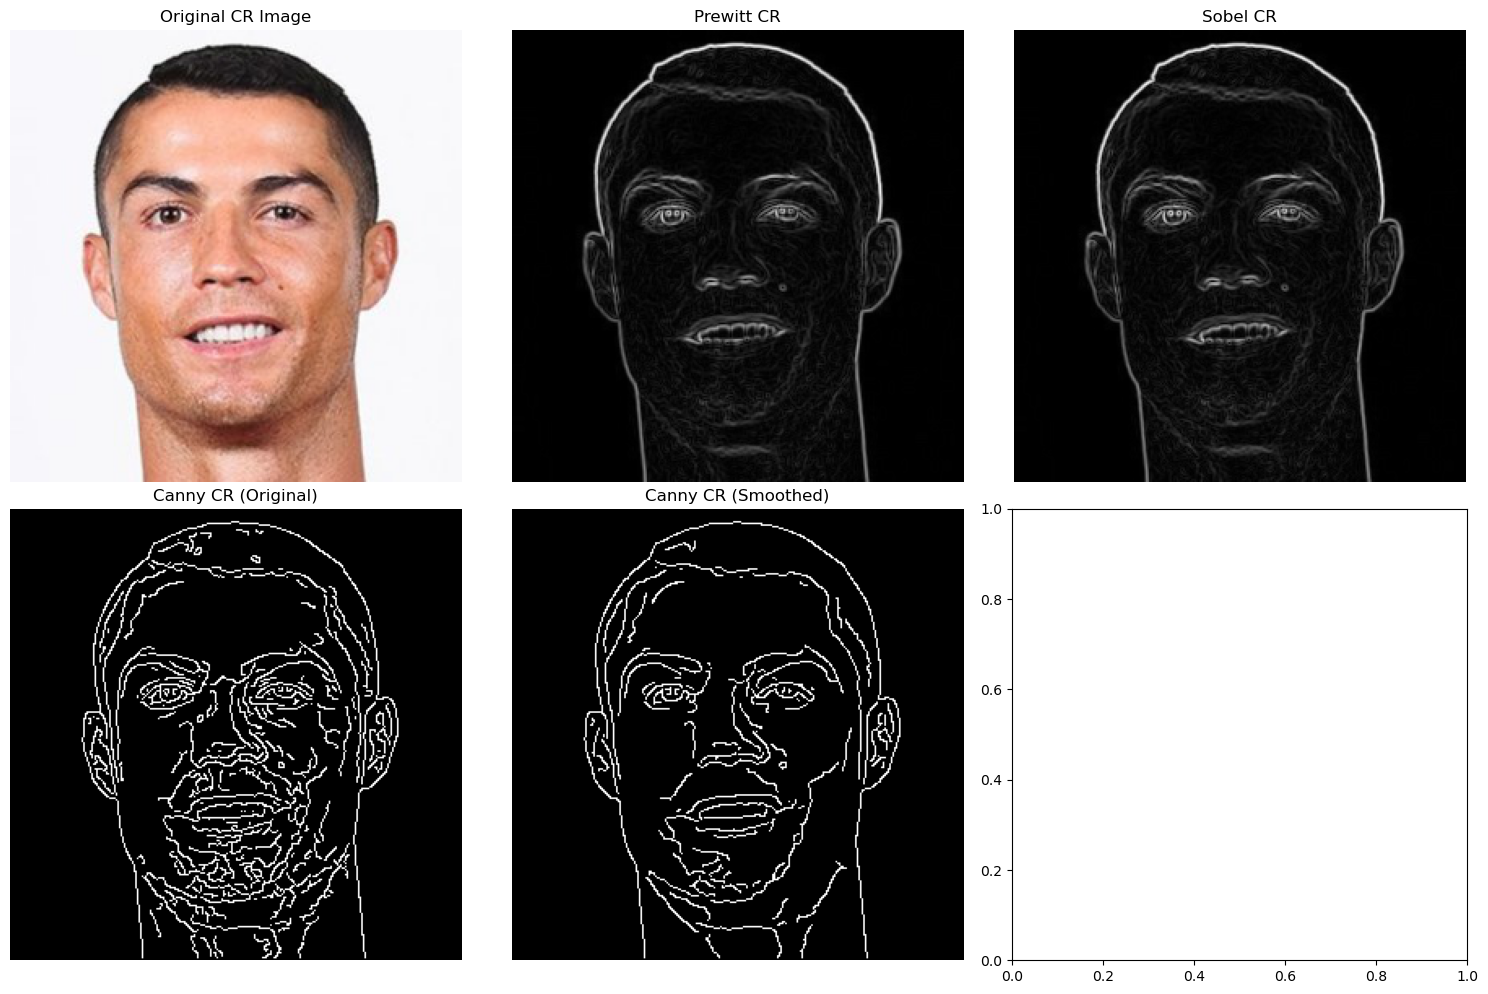

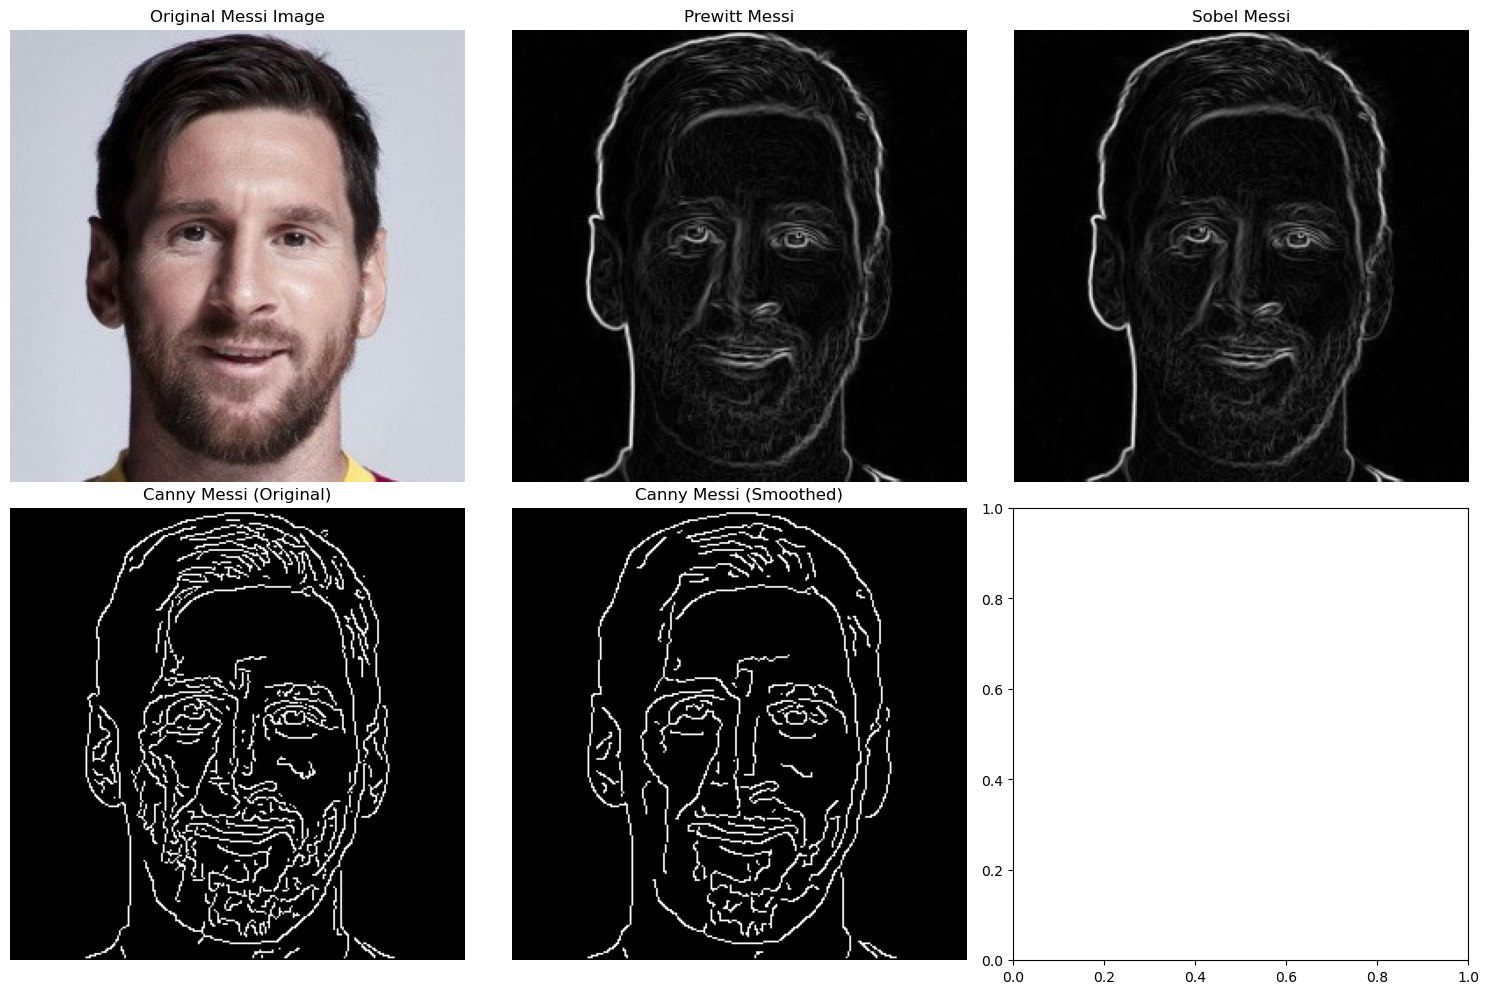

In [27]:
#your solution
# Load images cr.jpg and messi.jpg
image_cr_path = "images_notebook/cr.jpg"
image_messi_path = "images_notebook/messi.jpg"

# Load and convert to grayscale
image_cr = io.imread(image_cr_path)
image_cr_gray = rgb2gray(image_cr)

image_messi = io.imread(image_messi_path)
image_messi_gray = rgb2gray(image_messi)

# Apply Gaussian smoothing (with sigma=1) before edge detection
image_cr_smoothed = gaussian(image_cr_gray, sigma=1)
image_messi_smoothed = gaussian(image_messi_gray, sigma=1)

# Apply Prewitt filter
prewitt_cr = prewitt(image_cr_gray)
prewitt_messi = prewitt(image_messi_gray)

# Apply Sobel filter
sobel_cr = sobel(image_cr_gray)
sobel_messi = sobel(image_messi_gray)

# Apply Canny filter
canny_cr = canny(image_cr_gray, sigma=1)
canny_messi = canny(image_messi_gray, sigma=1)

# Apply edge detection on the smoothed images
canny_cr_smoothed = canny(image_cr_smoothed, sigma=1)
canny_messi_smoothed = canny(image_messi_smoothed, sigma=1)

# Plot results for CR image
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

ax[0, 0].imshow(image_cr, cmap='gray')
ax[0, 0].set_title("Original CR Image")
ax[0, 0].axis('off')

ax[0, 1].imshow(prewitt_cr, cmap='gray')
ax[0, 1].set_title("Prewitt CR")
ax[0, 1].axis('off')

ax[0, 2].imshow(sobel_cr, cmap='gray')
ax[0, 2].set_title("Sobel CR")
ax[0, 2].axis('off')

ax[1, 0].imshow(canny_cr, cmap='gray')
ax[1, 0].set_title("Canny CR (Original)")
ax[1, 0].axis('off')

ax[1, 1].imshow(canny_cr_smoothed, cmap='gray')
ax[1, 1].set_title("Canny CR (Smoothed)")
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Plot results for Messi image
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

ax[0, 0].imshow(image_messi, cmap='gray')
ax[0, 0].set_title("Original Messi Image")
ax[0, 0].axis('off')

ax[0, 1].imshow(prewitt_messi, cmap='gray')
ax[0, 1].set_title("Prewitt Messi")
ax[0, 1].axis('off')

ax[0, 2].imshow(sobel_messi, cmap='gray')
ax[0, 2].set_title("Sobel Messi")
ax[0, 2].axis('off')

ax[1, 0].imshow(canny_messi, cmap='gray')
ax[1, 0].set_title("Canny Messi (Original)")
ax[1, 0].axis('off')

ax[1, 1].imshow(canny_messi_smoothed, cmap='gray')
ax[1, 1].set_title("Canny Messi (Smoothed)")
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

1. **Are the contours improved if the image is previously smoothed?**

- Canny Filter (with and without smoothing)
  - For both **Cristiano Ronaldo** and **Messi** images, applying Gaussian smoothing before using the Canny filter significantly improved the contour extraction results.
  - Without smoothing, the original images contain texture, noise, and small details that introduce extra edges. For instance, in the Canny filter applied to the **CR image (Original)**, several unnecessary lines and noise are present in the face and around the eyes, lips, and hair. The same is observed in the **Messi image**, where the noise around the beard and hair creates extra, unwanted contours.
  - After **smoothing**, the Canny filter produces cleaner, more precise contours. For both faces, the edges focus more on the primary facial features, such as the outlines of the face, eyes, mouth, and ears, reducing the number of false positives in the textures.
  - A similar can be also obtained by tuning the **sigma parameter** in the Canny filter.
  - **Conclusion**: Pre-smoothing improves contour detection by removing small noise and texture that might otherwise result in extra edges. It helps highlight the main features and provides a cleaner, more defined contour map, especially for complex images like faces.

2. **Which are the limitations of the different images' contour extraction?**

- Prewitt and Sobel Filters
  - These gradient-based filters perform well at detecting large-scale edges but lack precision when it comes to fine details. In both the **CR** and **Messi** images, Prewitt and Sobel detect some major contours but struggle with distinguishing finer features, such as the lips, nose, or finer hair details.
  - These filters tend to detect gradients in both large and small areas equally, which makes them less suitable for images where we want to focus on specific, well-defined features.
  - Limitations
    - These filters may struggle with images that have a lot of texture or fine details, leading to noisy or incomplete edges.
    - They also do not include noise reduction steps, so they may detect unnecessary edges, especially in regions with subtle gradients, such as skin texture or beard hair.
- Canny Filter
  - While the Canny filter is much better at detecting fine details and producing clean edges, it is **sensitive to noise**. As we saw, without pre-smoothing, the Canny filter picks up extra edges related to noise and texture.
  - Limitations
    - The Canny filter depends heavily on parameters like the **sigma** (smoothing) and the thresholds used for edge detection. Improper tuning can lead to under-detection (if thresholds are too high) or over-detection (if thresholds are too low).
    - For very complex images, fine-tuning may be required to balance between over-smoothing and losing important contours.

c) Apply the Sobel and Prewwit filters using the `convolve` function instead of the `skimage.filters` package. Compare the results.


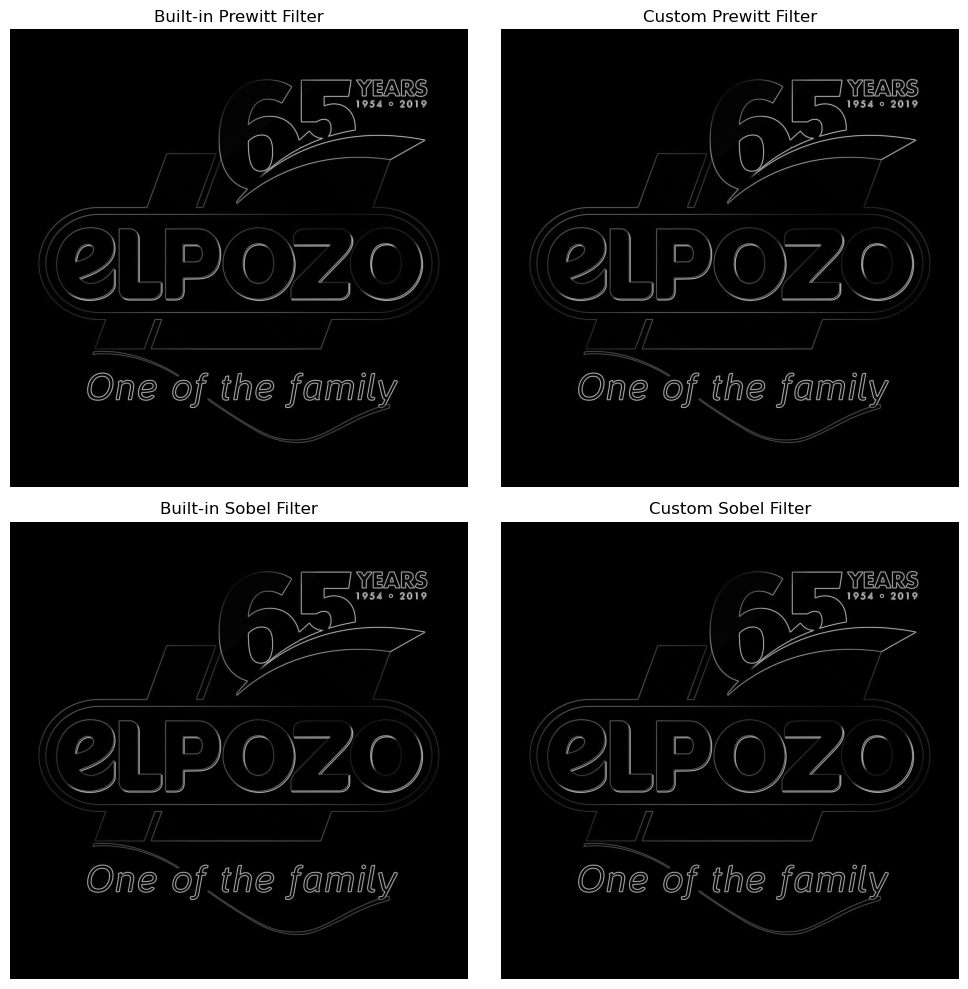

In [18]:
#your solution

from skimage.util import img_as_ubyte

def detect_edges(img, filter_x, filter_y, filters_normalized = False):
    """
    Params:
        img: The image where the edges will be detected. It needs to be uint8
            and in the range of [0, 255]
        filter_x: the filter used to detect vertical edges. Can be normalized or not
        filter_y: the filter used to detect horizontal edges. Can be normalized or not
        filters_normalized: True if the coefficients are normalized, False otherwise
    Returns:
        edges_img: The image containing the edges. It will be uint8 and in the
            range of [0, 255]
    """
    float_img = img_as_float(img)
    # Compute the derivatives in the x direction (i.e. vertical edges)
    vertical_edges_img = convolve(float_img, filter_x)
    # Compute the derivatives in the y direction (i.e. horizontal edges)
    horizontal_edges_img = convolve(float_img, filter_y)
    # Compute the gradient magnitude (i.e. edge strength)
    edges_img = np.sqrt(vertical_edges_img**2 + horizontal_edges_img**2)

    """ Normalize the gradients to be in the range of [0.0, 1.0]
        if the filters were not normalized """
    if not filters_normalized:
        min_value = np.min(edges_img)
        max_value = np.max(edges_img)
        edges_img = (edges_img - min_value) / (max_value - min_value)

    return img_as_ubyte(edges_img)

# Masks
sobel_filter_x = np.array([[1, 0, -1],
                           [2, 0, -2],
                           [1, 0, -1]])
sobel_filter_y = np.array([[1, 2, 1],
                           [0, 0, 0],
                           [-1, -2, -1]])

prewitt_filter_x = np.array([[1, 0, -1],
                             [1, 0, -1],
                             [1, 0, -1]])
prewitt_filter_y = np.array([[1, 1, 1],
                             [0, 0, 0],
                             [-1, -1, -1]])

# Convolve with Sobel
sobel_edges_img = detect_edges(logo_gray, sobel_filter_x, sobel_filter_y)
# convolve with Prewit
prewitt_edges_img = detect_edges(logo_gray, prewitt_filter_x, prewitt_filter_y)



# Plot the images in a 2x2 grid
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

# Built-in Prewitt
ax[0, 0].imshow(logo_pre, cmap='gray')
ax[0, 0].set_title("Built-in Prewitt Filter")
ax[0, 0].axis('off')

# Custom Prewitt
ax[0, 1].imshow(prewitt_edges_img, cmap='gray')
ax[0, 1].set_title("Custom Prewitt Filter")
ax[0, 1].axis('off')

# Built-in Sobel
ax[1, 0].imshow(logo_sob, cmap='gray')
ax[1, 0].set_title("Built-in Sobel Filter")
ax[1, 0].axis('off')

# Custom Sobel
ax[1, 1].imshow(sobel_edges_img, cmap='gray')
ax[1, 1].set_title("Custom Sobel Filter")
ax[1, 1].axis('off')

plt.tight_layout()
plt.show()

The custom Prewitt filter produces results very similar to the built-in Prewitt filter. The edges are well-defined, and the overall sharpness and clarity of the contours are nearly identical to the built-in implementation.
There may be slight variations in the intensity of the edges, but overall, the custom Prewitt filter closely replicates the built-in method.


The custom Sobel filter yields results that are nearly indistinguishable from the built-in Sobel filter. The edges are crisp and smooth, capturing the contours and text with the same precision as the built-in version.
Just like the Prewitt comparison, there may be slight variations in pixel intensity at the edges, but this difference is minimal and does not impact the overall detection quality.

### 2.6 Applying smoothing in order to obtain hybrid images

a) Given `./images_notebook/messi.jpg` and `./images_notebook/cr.jpg` images:

1. Plot both images.
2. Apply a low-pass filter to both of them and plot them.
3. Apply a high-pass filter to both of them and plot them.

The result should be something like:

![messi](images_notebook/Messi.png)

![cr](images_notebook/CR.png)


By applying smoothing over an image I, we apply a `low-pass` filter. The resulting image can be called L(I). If we substract the filtered one from the original image, we obtain its high frequencies, that we can call H(I), i.e. we apply a `high-pass` filter.

***H(I) = I - L(I)***

Hint: In order to highlight the effect, in the L(I) image you should define a lower sigma, while for the H(I) you should use a higher one.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5322055845031313..0.42444355073076173].


Text(0.5, 1.0, 'High Frequencies')

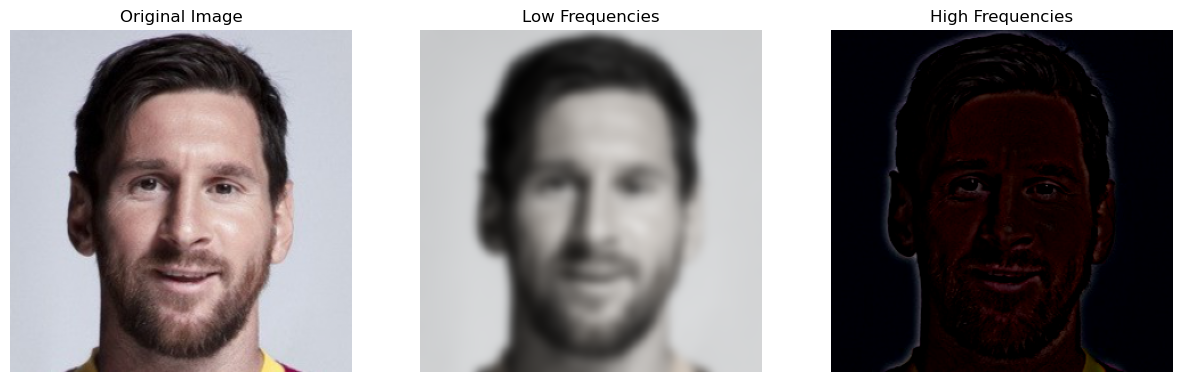

In [19]:
#your solution

from skimage import io
from skimage.color import rgb2gray
from skimage.filters import gaussian
from skimage.transform import resize

messi = io.imread("images_notebook/messi.jpg")

# Resize to common size of 256x256
messi = resize(messi, (300, 300))

messi_low = gaussian(messi, sigma=4)
messi_high = messi - messi_low

# Show all the images in a 1x3 grid
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Display the original image
ax[0].imshow(messi)
# Remove the ticks and axes
ax[0].axis("off")
# Add a title to the image
ax[0].set_title("Original Image")

ax[1].imshow(messi_low)
ax[1].axis("off")
ax[1].set_title("Low Frequencies")

ax[2].imshow(messi_high)
ax[2].axis("off")
ax[2].set_title("High Frequencies")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5502377890280108..0.5019420375273527].


Text(0.5, 1.0, 'High Frequencies')

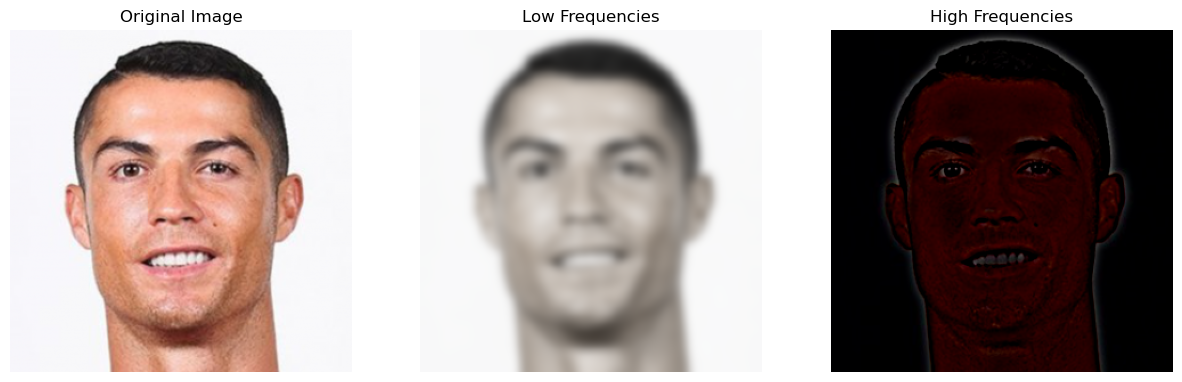

In [20]:
#your solution

cr = io.imread("images_notebook/cr.jpg")

# Resize to common size of 256x256
cr = resize(cr, (300, 300))

cr_low = gaussian(cr, sigma=4)
cr_high = cr - cr_low

# Show all the images in a 1x3 grid
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Display the original image
ax[0].imshow(cr)
# Remove the ticks and axes
ax[0].axis("off")
# Add a title to the image
ax[0].set_title("Original Image")

ax[1].imshow(cr_low)
ax[1].axis("off")
ax[1].set_title("Low Frequencies")

ax[2].imshow(cr_high)
ax[2].axis("off")
ax[2].set_title("High Frequencies")

b) Create hybrid images and visualize them. A hybrid image is obtained by combining the low and high frequencies of the image, i.e. combining the results obtained by the `low-pass` and `high-pass` filters.

<img src="images_notebook/Fusion.gif" width="400" height="400">

Hybrid (I1, I2) = L(I1) + H(I2)

1. Analyze which is the best way of showing it if our aim is to see Messi's face.
2. Additionally, rescale the image to a different size and comment the results.

Present the different visualizations of the experiment performed.

<img src="images_notebook/Hybrid.png">


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0036690543026569322..1.2803064362240035].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.34303866679147144..1.1540982249655594].


Text(0.5, 1.0, 'Hybrid Image 2')

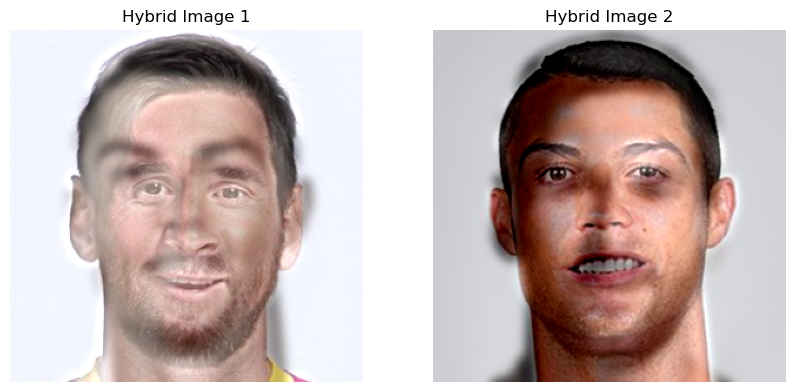

In [ ]:
#your solution
hybrid_1 = 2*(0.5*cr_low + 0.5*messi_high)
hybrid_2= 2*(0.5*messi_low + 0.5*cr_high)



# Show all the images in a 1x2 grid
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
ax[0].imshow(hybrid_1)
# Remove the ticks and axes
ax[0].axis("off")
# Add a title to the image
ax[0].set_title("Hybrid Image 1")

ax[1].imshow(hybrid_2)
ax[1].axis("off")
ax[1].set_title("Hybrid Image 2")

### 2.7 Anonimization of sensitive information

One of the important problems in Computer Vision as a science that manages data (images and videos) is the anonimization of sensitive information appearing in the images.
For example, it is common in applications like Google Street View, where the faces and license plates are anonymized.
The file `./images_notebook/car.png` contains two cars. Anonimize the license plates of the cars using the techniques learned in this practicum.

Modify only the license plates of the cars, keeping the rest of the image unchanged.

![car](images_notebook/car.png)

### 2.7 Anonimización de información sensible

Uno de los problemas importantes en la visión artificial como ciencia que gestiona datos (imágenes y vídeos) es la anonimización de la información sensible que aparece en las imágenes.
Por ejemplo, es habitual en aplicaciones como Google Street View, donde se anonimizan los rostros y las matrículas.
El archivo `./images_notebook/car.png` contiene dos coches. Anonimice las matrículas de los coches utilizando las técnicas aprendidas en este trabajo práctico.

Modifique solo las matrículas de los coches, manteniendo el resto de la imagen sin cambios.

![car](images_notebook/car.png)

(473, 806, 3)


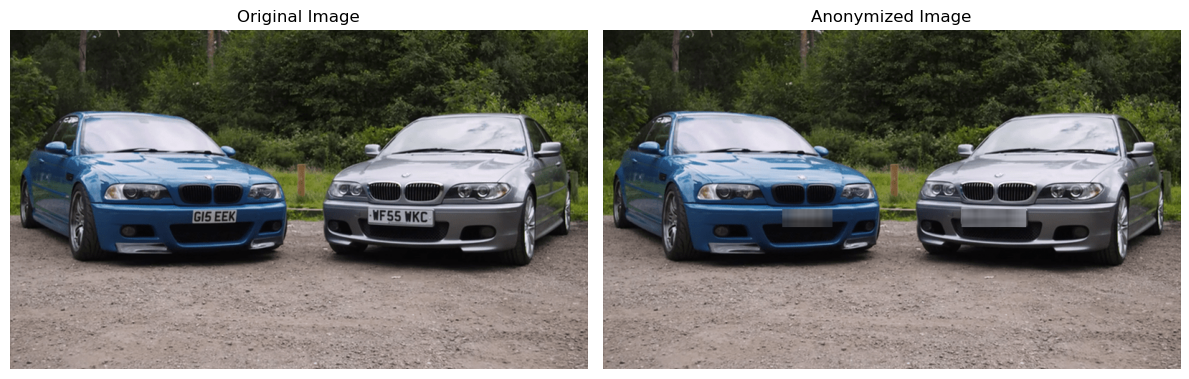

In [29]:
image = io.imread("images_notebook/car.png")

print(image.shape)

# Convert image to float (better for manipulation)
image_float = img_as_float(image)

# Define coordinates of the license plates (manually identified)
# Example: (start_row, start_col), (end_row, end_col) for two plates
license_plate_1 = ((250, 250), (275, 320))  # Example coordinates for first car's license plate
license_plate_2 = ((250, 500), (275, 590))  # Example coordinates for second car's license plate

# Function to anonymize license plate by applying a blur
def anonymize_region(image, top_left, bottom_right):
    """ Anonymizes the region by blurring it. """
    # Extract the region to be anonymized
    region = image[top_left[0]:bottom_right[0], top_left[1]:bottom_right[1]]

    # Apply Gaussian blur to the region
    mask_3d = np.ones((25, 25))
    blurred_region = conv_coor(region, mask_3d)

    # Replace the original region with the blurred one
    image[top_left[0]:bottom_right[0], top_left[1]:bottom_right[1]] = blurred_region

# Anonymize both license plates
anonymize_region(image_float, license_plate_1[0], license_plate_1[1])
anonymize_region(image_float, license_plate_2[0], license_plate_2[1])

# Plot the original and anonymized images side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Display original image
ax[0].imshow(image)
ax[0].set_title('Original Image')
ax[0].axis('off')

# Display anonymized image
ax[1].imshow(image_float)
ax[1].set_title('Anonymized Image')
ax[1].axis('off')

plt.tight_layout()
plt.show()